# NB08c — Phase 1B Metric Diagnostic: Tree-Aware (Sankoff) vs Parent-Rank Dispersion

**Project**: Gene Function Ecological Agora — Innovation Atlas Across the Bacterial Tree  
**Phase**: 1B — post-gate methodology diagnostic (after NB08, NB08b, Alm 2006 close-reading)  
**Purpose**: Run four diagnostics (A + B + C + D) to determine whether the Phase 1B order-rank anomaly is a metric artifact (parent-rank dispersion specifically) or a deeper methodology failure. Diagnostic C — **Sankoff parsimony on the GTDB-r214 tree** — is the headline: it's the lightweight equivalent of Alm 2006's tree-aware reconciliation and the canonical test of whether a tree-aware metric recovers HGT signal where parent-rank dispersion fails.

## The four diagnostics

- **A** — Per-class K (n_clades_with) distribution at order rank. Tests whether positive HGT controls have systematically smaller K than negative controls, which would explain anomalous z patterns via metric bias on small K.
- **B** — Per-phylum decomposition. Within Pseudomonadota only, do positive HGT controls show less clumping than negative controls? If yes, cross-phylum mixing is the artifact.
- **C** — **Sankoff parsimony on GTDB-r214 tree** *(HEADLINE)*. For each UniRef50: minimum gain events on the species tree topology. HGT-active classes should show higher parsimony scores than vertically-inherited classes.
- **D** — Annotation density check. Fraction of UniRefs in each class whose dominant phylum is Pseudomonadota (testing AMRFinderPlus reference bias).

## Inputs

- `data/p1b_full_scores.parquet` — per-(rank, clade, UniRef50) producer + consumer z-scores
- `data/p1b_full_species.tsv` — 18,989 species with rank scaffold
- `data/p1b_full_uniref50.tsv` — 100,192 UniRef50s with control_class
- `data/p1b_full_extract_local.parquet` — (species, UniRef50, paralog) presence rows
- `user_data/bac120_r214.tree` — GTDB r214.0 bacterial species tree (newick, 4.2 MB, 80,789 leaves; 100 % coverage of Phase 1B species reps verified)

## Outputs

- `data/p1b_diagnostic_K_distribution.tsv` — Diagnostic A
- `data/p1b_diagnostic_per_phylum.tsv` — Diagnostic B
- `data/p1b_diagnostic_sankoff_parsimony.tsv` — Diagnostic C **(HEADLINE)**
- `data/p1b_diagnostic_phylum_concentration.tsv` — Diagnostic D
- `data/p1b_metric_diagnostic_log.json` — full diagnostics log
- `figures/p1b_metric_diagnostic_panels.png` — 4-panel diagnostic figure

## What the headline diagnostic decides

If Diagnostic C shows **HGT-active classes (β-lactamase, CRISPR-Cas, AMR, CAZymes) have higher Sankoff parsimony scores than housekeeping negatives at p < 0.001 with Cohen's d ≥ 0.3**, the order-rank anomaly is a parent-rank-dispersion artifact and the methodology is recoverable with a tree-aware metric in Phase 2.

If Diagnostic C *also* fails to discriminate HGT from vertical, the consumer-null framework has a structural problem and Phase 2 needs a deeper redesign before scaling.

## Setup + load data + prune GTDB tree to Phase 1B species reps

In [1]:
import json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

PROJECT_ROOT = Path("/home/aparkin/BERIL-research-observatory/projects/gene_function_ecological_agora")
DATA_DIR = PROJECT_ROOT / "data"
FIG_DIR = PROJECT_ROOT / "figures"
USER_DATA = PROJECT_ROOT / "user_data"

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

diagnostics = {
    "timestamp_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
    "seed": RNG_SEED,
    "purpose": "Sankoff parsimony + 3 sanity diagnostics on Phase 1B order-rank anomaly",
}

# Load Phase 1B data
scores = pd.read_parquet(DATA_DIR / "p1b_full_scores.parquet")
species_df = pd.read_csv(DATA_DIR / "p1b_full_species.tsv", sep="\t")
uniref_df = pd.read_csv(DATA_DIR / "p1b_full_uniref50.tsv", sep="\t")
extract_df = pd.read_parquet(DATA_DIR / "p1b_full_extract_local.parquet")

# Map species clade ID → representative genome ID (the tree leaf name)
clade_to_rep = species_df.set_index("gtdb_species_clade_id")["representative_genome_id"].to_dict()
rep_to_phylum = species_df.set_index("representative_genome_id")["phylum"].to_dict()
rep_ids_set = set(species_df["representative_genome_id"])

print(f"Phase 1B substrate: {len(species_df):,} species, {len(uniref_df):,} UniRef50s, {len(extract_df):,} presences, {len(scores):,} scores")

Phase 1B substrate: 18,989 species, 100,192 UniRef50s, 1,539,643 presences, 1,294,615 scores


In [2]:
tree_path = USER_DATA / "bac120_r214.tree"

# Pure-Python newick parser + custom prune (avoids ete3's Python 3.13 incompatibility)
class Node:
    __slots__ = ("name", "children", "parent")
    def __init__(self, name="", children=None, parent=None):
        self.name = name
        self.children = children if children is not None else []
        self.parent = parent
    def is_leaf(self):
        return not self.children

def parse_newick(s):
    """Recursive-descent newick parser. Returns root Node. Strips quotes/branch lengths/bootstrap."""
    pos = [0]
    def skip_ws():
        while pos[0] < len(s) and s[pos[0]].isspace():
            pos[0] += 1
    def parse_node(parent=None):
        skip_ws()
        children = []
        if pos[0] < len(s) and s[pos[0]] == "(":
            pos[0] += 1
            children.append(parse_node())
            skip_ws()
            while pos[0] < len(s) and s[pos[0]] == ",":
                pos[0] += 1
                children.append(parse_node())
                skip_ws()
            assert s[pos[0]] == ")", f"Expected ) at {pos[0]}"
            pos[0] += 1
        # Read name + optional branch length. Newick allows single-quoted names
        # (GTDB uses these for internal-node taxonomic labels, which contain ':' and ';').
        skip_ws()
        name_start = pos[0]
        # If quoted, scan past the matching close quote first
        if pos[0] < len(s) and s[pos[0]] == "'":
            pos[0] += 1
            while pos[0] < len(s) and s[pos[0]] != "'":
                pos[0] += 1
            if pos[0] < len(s):
                pos[0] += 1  # skip closing quote
        # Now consume any trailing ":branch_length" up to the next structural char
        while pos[0] < len(s) and s[pos[0]] not in ",();":
            pos[0] += 1
        token = s[name_start:pos[0]]
        # Extract name: if quoted, take inside-quote text; else everything before ':'
        if token.startswith("'") and "'" in token[1:]:
            name_part = token[1:token.find("'", 1)]
        else:
            name_part = token.split(":")[0].strip().strip("'")
        node = Node(name=name_part, children=children, parent=parent)
        for c in children:
            c.parent = node
        return node
    return parse_node()

print(f"Loading {tree_path.name} ({tree_path.stat().st_size / 1e6:.1f} MB)...")
with open(tree_path) as f:
    newick_text = f.read()
t0 = time.time()
tree = parse_newick(newick_text)
all_leaves = []
def _collect(node):
    if node.is_leaf():
        all_leaves.append(node)
    else:
        for c in node.children:
            _collect(c)
_collect(tree)
print(f"Parsed in {time.time()-t0:.1f}s. Full tree: {len(all_leaves):,} leaves")
diagnostics["tree_n_leaves_full"] = len(all_leaves)

# Custom prune: keep only Phase 1B reps; collapse unary internals
def prune_tree(node, keep_set):
    if node.is_leaf():
        return node if node.name in keep_set else None
    kept = [prune_tree(c, keep_set) for c in node.children]
    kept = [c for c in kept if c is not None]
    if not kept:
        return None
    if len(kept) == 1:
        return kept[0]
    node.children = kept
    for c in kept:
        c.parent = node
    return node

t0 = time.time()
tree = prune_tree(tree, rep_ids_set)
pruned_leaves = []
_collect(tree); pruned_leaves = list(all_leaves) if False else []
def _collect2(node, out):
    if node.is_leaf():
        out.append(node)
    else:
        for c in node.children:
            _collect2(c, out)
pruned_leaves = []
_collect2(tree, pruned_leaves)
print(f"Pruned in {time.time()-t0:.1f}s. Pruned tree: {len(pruned_leaves):,} leaves")
diagnostics["tree_n_leaves_pruned"] = len(pruned_leaves)

# Pre-compute post-order traversal (iterative, avoids recursion-limit issues)
def postorder(root):
    out = []
    stack = [(root, False)]
    while stack:
        node, visited = stack.pop()
        if visited:
            out.append(node)
        else:
            stack.append((node, True))
            for child in node.children:
                stack.append((child, False))
    return out

postorder_list = postorder(tree)
print(f"Post-order list: {len(postorder_list):,} nodes")

Loading bac120_r214.tree (4.2 MB)...


Parsed in 0.8s. Full tree: 80,789 leaves
Pruned in 0.0s. Pruned tree: 18,989 leaves
Post-order list: 37,977 nodes


## Diagnostic A — Per-class K (n_clades_with) distribution at order rank

In [3]:
# K = n_clades_with is in scores_df at each rank for each UniRef. Get unique (uniref, rank, n_clades_with).
K_per_uref = (
    scores[scores["rank"] == "order"]
    [["uniref50_id", "n_clades_with", "control_class"]]
    .drop_duplicates(subset=["uniref50_id"])
    .copy()
)
K_per_uref = K_per_uref[K_per_uref["n_clades_with"].notna()]

rows = []
for cls, sub in K_per_uref.groupby("control_class"):
    rows.append({
        "control_class": cls, "n": len(sub),
        "K_mean": round(sub["n_clades_with"].mean(), 2),
        "K_median": round(sub["n_clades_with"].median(), 2),
        "K_q25": round(sub["n_clades_with"].quantile(0.25), 2),
        "K_q75": round(sub["n_clades_with"].quantile(0.75), 2),
    })
K_summary = pd.DataFrame(rows).sort_values("K_median", ascending=False)
K_summary.to_csv(DATA_DIR / "p1b_diagnostic_K_distribution.tsv", sep="\t", index=False)
print("Per-class K (n_clades_with at order rank) distribution:")
print(K_summary.to_string(index=False))

# Mann-Whitney pos HGT vs neg housekeeping
pos_K = K_per_uref[K_per_uref["control_class"].isin(["pos_amr", "pos_betalac", "pos_crispr_cas"])]["n_clades_with"]
neg_K = K_per_uref[K_per_uref["control_class"].isin(["neg_ribosomal", "neg_trna_synth", "neg_rnap_core"])]["n_clades_with"]
if len(pos_K) >= 3 and len(neg_K) >= 3:
    u, p_two = stats.mannwhitneyu(pos_K, neg_K, alternative="two-sided")
    print(f"\nMann-Whitney: pos HGT median K = {pos_K.median():.0f}, neg housekeeping median K = {neg_K.median():.0f}, p (two-sided) = {p_two:.2e}")
    diagnostics["diag_A_pos_K_median"] = float(pos_K.median())
    diagnostics["diag_A_neg_K_median"] = float(neg_K.median())
    diagnostics["diag_A_p_two_sided"] = float(p_two)

Per-class K (n_clades_with at order rank) distribution:
    control_class     n  K_mean  K_median  K_q25  K_q75
natural_expansion 10030    4.03       2.0    1.0    4.0
          pos_amr  3656    4.24       2.0    1.0    4.0
       hyp_cazyme  9988    1.56       1.0    1.0    1.0
    neg_ribosomal 10063    2.70       1.0    1.0    2.0
   neg_trna_synth 10044    2.40       1.0    1.0    2.0
    neg_rnap_core  3602    2.90       1.0    1.0    2.0
             none 29773    1.29       1.0    1.0    1.0
      pos_betalac  9909    1.37       1.0    1.0    1.0
   pos_crispr_cas  2963    2.17       1.0    1.0    2.0
       pos_tcs_hk 10082    1.28       1.0    1.0    1.0

Mann-Whitney: pos HGT median K = 1, neg housekeeping median K = 1, p (two-sided) = 7.54e-20


## Diagnostic D — Annotation density check (phylum concentration)

In [4]:
# Per UniRef: fraction of its species presences that are Pseudomonadota
extract_with_phylum = extract_df.merge(
    species_df[["gtdb_species_clade_id", "phylum"]],
    on="gtdb_species_clade_id", how="left",
)
extract_with_phylum["is_pseudo"] = (extract_with_phylum["phylum"] == "p__Pseudomonadota").astype(int)

uref_pseudo_frac = (
    extract_with_phylum[extract_with_phylum["is_present"]]
    .groupby("uniref50_id")
    .agg(n_species=("is_pseudo", "size"), n_pseudo=("is_pseudo", "sum"))
    .reset_index()
)
uref_pseudo_frac["pseudo_fraction"] = uref_pseudo_frac["n_pseudo"] / uref_pseudo_frac["n_species"]
uref_pseudo_frac = uref_pseudo_frac.merge(uniref_df[["uniref50_id", "control_class"]], on="uniref50_id")

rows = []
for cls, sub in uref_pseudo_frac.groupby("control_class"):
    rows.append({
        "control_class": cls, "n_urefs": len(sub),
        "median_pseudo_fraction": round(sub["pseudo_fraction"].median(), 3),
        "mean_pseudo_fraction": round(sub["pseudo_fraction"].mean(), 3),
        "frac_urefs_>50pct_pseudo": round((sub["pseudo_fraction"] > 0.5).mean(), 3),
        "frac_urefs_>90pct_pseudo": round((sub["pseudo_fraction"] > 0.9).mean(), 3),
    })
phylum_concentration = pd.DataFrame(rows).sort_values("median_pseudo_fraction", ascending=False)
phylum_concentration.to_csv(DATA_DIR / "p1b_diagnostic_phylum_concentration.tsv", sep="\t", index=False)
print("Phylum concentration check (Pseudomonadota dominance per UniRef):")
print(phylum_concentration.to_string(index=False))
diagnostics["diag_D_summary"] = phylum_concentration.to_dict(orient="records")

Phylum concentration check (Pseudomonadota dominance per UniRef):
    control_class  n_urefs  median_pseudo_fraction  mean_pseudo_fraction  frac_urefs_>50pct_pseudo  frac_urefs_>90pct_pseudo
          pos_amr     3656                   0.500                 0.489                     0.492                     0.418
natural_expansion    10030                   0.037                 0.452                     0.455                     0.416
       hyp_cazyme     9993                   0.000                 0.174                     0.171                     0.162
    neg_ribosomal    10077                   0.000                 0.222                     0.218                     0.202
   neg_trna_synth    10070                   0.000                 0.264                     0.260                     0.238
    neg_rnap_core     3606                   0.000                 0.220                     0.213                     0.179
             none    29790                   0.000         

## Diagnostic B — Per-phylum decomposition (within-Pseudomonadota analysis)

In [5]:
# Within-Pseudomonadota analysis: count distinct families per UniRef restricted to Pseudomonadota species
PSEUDO = "p__Pseudomonadota"
pseudo_extract = extract_with_phylum[(extract_with_phylum["phylum"] == PSEUDO) & (extract_with_phylum["is_present"])]
pseudo_species_to_family = species_df[species_df["phylum"] == PSEUDO].set_index("gtdb_species_clade_id")["family"].to_dict()
pseudo_extract = pseudo_extract.copy()
pseudo_extract["family"] = pseudo_extract["gtdb_species_clade_id"].map(pseudo_species_to_family)

# For each UniRef restricted to Pseudomonadota: dispersion = n_distinct_families / n_distinct_species
# (analogous to parent-rank dispersion but within Pseudomonadota only)
pseudo_per_uref = (
    pseudo_extract.groupby("uniref50_id")
    .agg(n_pseudo_species=("gtdb_species_clade_id", "nunique"),
         n_pseudo_families=("family", "nunique"))
    .reset_index()
)
pseudo_per_uref = pseudo_per_uref[pseudo_per_uref["n_pseudo_species"] >= 3]
pseudo_per_uref["within_pseudo_dispersion"] = pseudo_per_uref["n_pseudo_families"] / pseudo_per_uref["n_pseudo_species"]
pseudo_per_uref = pseudo_per_uref.merge(uniref_df[["uniref50_id", "control_class"]], on="uniref50_id")

rows = []
for cls, sub in pseudo_per_uref.groupby("control_class"):
    if len(sub) < 3:
        continue
    rows.append({
        "control_class": cls, "n_urefs_in_pseudo": len(sub),
        "median_within_pseudo_dispersion": round(sub["within_pseudo_dispersion"].median(), 3),
        "mean_within_pseudo_dispersion": round(sub["within_pseudo_dispersion"].mean(), 3),
        "q25": round(sub["within_pseudo_dispersion"].quantile(0.25), 3),
        "q75": round(sub["within_pseudo_dispersion"].quantile(0.75), 3),
    })
B_summary = pd.DataFrame(rows).sort_values("median_within_pseudo_dispersion", ascending=False)
B_summary.to_csv(DATA_DIR / "p1b_diagnostic_per_phylum.tsv", sep="\t", index=False)
print("Within-Pseudomonadota dispersion per class (n_families / n_species):")
print(B_summary.to_string(index=False))

# Mann-Whitney within Pseudomonadota: pos HGT vs neg housekeeping
pseudo_pos = pseudo_per_uref[pseudo_per_uref["control_class"].isin(["pos_amr", "pos_betalac", "pos_crispr_cas"])]["within_pseudo_dispersion"]
pseudo_neg = pseudo_per_uref[pseudo_per_uref["control_class"].isin(["neg_ribosomal", "neg_trna_synth", "neg_rnap_core"])]["within_pseudo_dispersion"]
if len(pseudo_pos) >= 3 and len(pseudo_neg) >= 3:
    u, p = stats.mannwhitneyu(pseudo_pos, pseudo_neg, alternative="greater")
    print(f"\nWithin-Pseudomonadota Mann-Whitney pos vs neg (greater): pos median = {pseudo_pos.median():.3f}, neg median = {pseudo_neg.median():.3f}, p = {p:.2e}")
    diagnostics["diag_B_pseudo_pos_median"] = float(pseudo_pos.median())
    diagnostics["diag_B_pseudo_neg_median"] = float(pseudo_neg.median())
    diagnostics["diag_B_p_one_sided_greater"] = float(p)

Within-Pseudomonadota dispersion per class (n_families / n_species):
    control_class  n_urefs_in_pseudo  median_within_pseudo_dispersion  mean_within_pseudo_dispersion   q25   q75
    neg_rnap_core                464                            0.400                          0.450 0.213 0.667
   neg_trna_synth               1363                            0.333                          0.375 0.152 0.545
   pos_crispr_cas                374                            0.333                          0.348 0.167 0.449
             none               2773                            0.308                          0.332 0.167 0.400
    neg_ribosomal               1355                            0.250                          0.332 0.125 0.500
       hyp_cazyme                704                            0.250                          0.302 0.135 0.339
      pos_betalac               1055                            0.250                          0.308 0.125 0.394
          pos_amr          

## Diagnostic C — Sankoff parsimony on GTDB-r214 tree (HEADLINE)

For each sampled UniRef50: compute the minimum number of gain events (Fitch parsimony score on binary 0/1 trait) on the pruned GTDB tree. UniRefs requiring many independent gains have HGT-like patterns; UniRefs requiring few gains are vertically inherited from a single common ancestor.

In [6]:
def fitch_parsimony_score(postorder_nodes, present_leaves_set):
    """Compute Fitch's binary-trait parsimony score using pre-computed post-order list.
    Returns the number of internal nodes where children disagreed = minimum
    independent gains needed to explain the presence pattern (assumes root absent).
    """
    states = {}
    union_count = 0
    for node in postorder_nodes:
        if node.is_leaf():
            states[id(node)] = 1 if node.name in present_leaves_set else 0
        else:
            child_states = set(states[id(c)] for c in node.children)
            if len(child_states) == 1:
                states[id(node)] = next(iter(child_states))
            else:
                # Children disagreed; node state is union (here {0,1}) → encode as 2
                states[id(node)] = 2
                union_count += 1
    return union_count

# Sample: 500 UniRefs per class (or all if < 500). Sankoff on 100K UniRefs is overkill;
# 500/class × 9 classes = 4500 UniRefs is a good pilot subset.
SAMPLE_PER_CLASS = 500
diagnostics["diag_C_sample_per_class"] = SAMPLE_PER_CLASS

# Pre-compute species → presence list per UniRef (only UniRefs in extract)
# Map species_clade_id → rep_id (tree leaf name)
extract_with_rep = extract_df[extract_df["is_present"]].copy()
extract_with_rep["rep_id"] = extract_with_rep["gtdb_species_clade_id"].map(clade_to_rep)
uref_to_present_reps = extract_with_rep.groupby("uniref50_id")["rep_id"].apply(set).to_dict()

# Sample per class
sampled_urefs = []
for cls, group in uniref_df.groupby("control_class"):
    n_take = min(SAMPLE_PER_CLASS, len(group))
    if n_take == 0:
        continue
    sampled = group.sample(n=n_take, random_state=RNG_SEED)
    for uref_id in sampled["uniref50_id"]:
        sampled_urefs.append((uref_id, cls))

print(f"Sankoff parsimony on {len(sampled_urefs)} UniRefs across {uniref_df['control_class'].nunique()} classes...")

Sankoff parsimony on 5000 UniRefs across 10 classes...


In [7]:
# Compute parsimony scores
t0 = time.time()
rows = []
n_done = 0
for uref_id, cls in sampled_urefs:
    present = uref_to_present_reps.get(uref_id, set())
    # Restrict to leaves in pruned tree
    present_in_tree = present & rep_ids_set
    n_present = len(present_in_tree)
    if n_present == 0:
        continue
    score = fitch_parsimony_score(postorder_list, present_in_tree)
    rows.append({
        "uniref50_id": uref_id, "control_class": cls,
        "n_present_leaves": n_present,
        "sankoff_parsimony_score": int(score),
        "score_per_present": round(score / n_present, 3) if n_present > 0 else np.nan,
    })
    n_done += 1
    if n_done % 500 == 0:
        elapsed = time.time() - t0
        rate = n_done / elapsed
        eta = (len(sampled_urefs) - n_done) / rate
        print(f"  {n_done}/{len(sampled_urefs)} done ({rate:.1f} UniRefs/s, ETA {eta:.0f}s)")

sankoff_df = pd.DataFrame(rows)
elapsed = time.time() - t0
print(f"\nSankoff complete in {elapsed:.1f}s ({len(sankoff_df)} UniRefs scored)")
diagnostics["diag_C_n_scored"] = int(len(sankoff_df))
diagnostics["diag_C_elapsed_s"] = float(elapsed)

  500/5000 done (73.9 UniRefs/s, ETA 61s)


  1000/5000 done (72.9 UniRefs/s, ETA 55s)


  1500/5000 done (72.8 UniRefs/s, ETA 48s)


  2000/5000 done (72.7 UniRefs/s, ETA 41s)


  2500/5000 done (72.7 UniRefs/s, ETA 34s)


  3000/5000 done (72.6 UniRefs/s, ETA 28s)


  3500/5000 done (72.4 UniRefs/s, ETA 21s)


  4000/5000 done (72.4 UniRefs/s, ETA 14s)


  4500/5000 done (72.3 UniRefs/s, ETA 7s)


  5000/5000 done (72.3 UniRefs/s, ETA 0s)

Sankoff complete in 69.1s (5000 UniRefs scored)


In [8]:
# Per-class Sankoff parsimony summary
rows = []
for cls, sub in sankoff_df.groupby("control_class"):
    rows.append({
        "control_class": cls, "n": len(sub),
        "median_score": round(sub["sankoff_parsimony_score"].median(), 1),
        "mean_score": round(sub["sankoff_parsimony_score"].mean(), 1),
        "median_score_per_present": round(sub["score_per_present"].median(), 3),
        "mean_score_per_present": round(sub["score_per_present"].mean(), 3),
        "q25_score": round(sub["sankoff_parsimony_score"].quantile(0.25), 1),
        "q75_score": round(sub["sankoff_parsimony_score"].quantile(0.75), 1),
    })
sankoff_summary = pd.DataFrame(rows).sort_values("median_score_per_present", ascending=False)
sankoff_summary.to_csv(DATA_DIR / "p1b_diagnostic_sankoff_parsimony.tsv", sep="\t", index=False)
print("=== HEADLINE: Per-class Sankoff parsimony score ===")
print("(higher = more independent gains = HGT-like; lower = vertical inheritance)")
print()
print(sankoff_summary.to_string(index=False))

# Mann-Whitney pos HGT vs neg housekeeping on score_per_present
pos_sankoff = sankoff_df[sankoff_df["control_class"].isin(["pos_amr", "pos_betalac", "pos_crispr_cas"])]["score_per_present"]
neg_sankoff = sankoff_df[sankoff_df["control_class"].isin(["neg_ribosomal", "neg_trna_synth", "neg_rnap_core"])]["score_per_present"]
u, p = stats.mannwhitneyu(pos_sankoff, neg_sankoff, alternative="greater")
median_diff = pos_sankoff.median() - neg_sankoff.median()
# Cohen's d on score_per_present
pooled_std = np.sqrt(((len(pos_sankoff)-1)*pos_sankoff.var() + (len(neg_sankoff)-1)*neg_sankoff.var()) / (len(pos_sankoff)+len(neg_sankoff)-2))
cohens_d = (pos_sankoff.mean() - neg_sankoff.mean()) / pooled_std if pooled_std > 0 else 0.0
print(f"\n*** HEADLINE TEST: pos HGT vs neg housekeeping (Sankoff/n_present) ***")
print(f"  pos HGT median = {pos_sankoff.median():.3f}")
print(f"  neg housekeeping median = {neg_sankoff.median():.3f}")
print(f"  median difference = {median_diff:+.3f}")
print(f"  Cohen's d = {cohens_d:+.3f}")
print(f"  Mann-Whitney p (one-sided greater) = {p:.2e}")
if p < 1e-3 and abs(cohens_d) >= 0.3:
    print(f"  → HEADLINE PASS: tree-aware metric DISCRIMINATES at p<0.001 + d≥0.3")
elif p < 0.05:
    print(f"  → MARGINAL: tree-aware metric discriminates statistically but with small effect size")
else:
    print(f"  → HEADLINE FAIL: tree-aware metric does NOT discriminate. Methodology has deeper issues.")
diagnostics["diag_C_pos_median"] = float(pos_sankoff.median())
diagnostics["diag_C_neg_median"] = float(neg_sankoff.median())
diagnostics["diag_C_cohens_d"] = float(cohens_d)
diagnostics["diag_C_mw_p"] = float(p)
diagnostics["diag_C_median_diff"] = float(median_diff)

=== HEADLINE: Per-class Sankoff parsimony score ===
(higher = more independent gains = HGT-like; lower = vertical inheritance)

    control_class   n  median_score  mean_score  median_score_per_present  mean_score_per_present  q25_score  q75_score
             none 500          37.0        42.8                    24.500                  25.594       28.0       48.2
       pos_tcs_hk 500          35.0        43.9                    19.750                  21.525       26.0       46.0
      pos_betalac 500          34.0        41.3                    19.000                  21.455       25.0       46.0
       hyp_cazyme 500          38.0        51.9                    19.000                  21.352       26.8       52.0
    neg_rnap_core 500          39.0        64.3                    17.466                  19.501       27.0       63.5
   pos_crispr_cas 500          41.0        59.2                    17.000                  20.478       28.0       56.0
   neg_trna_synth 500          3

## Synthesis figure

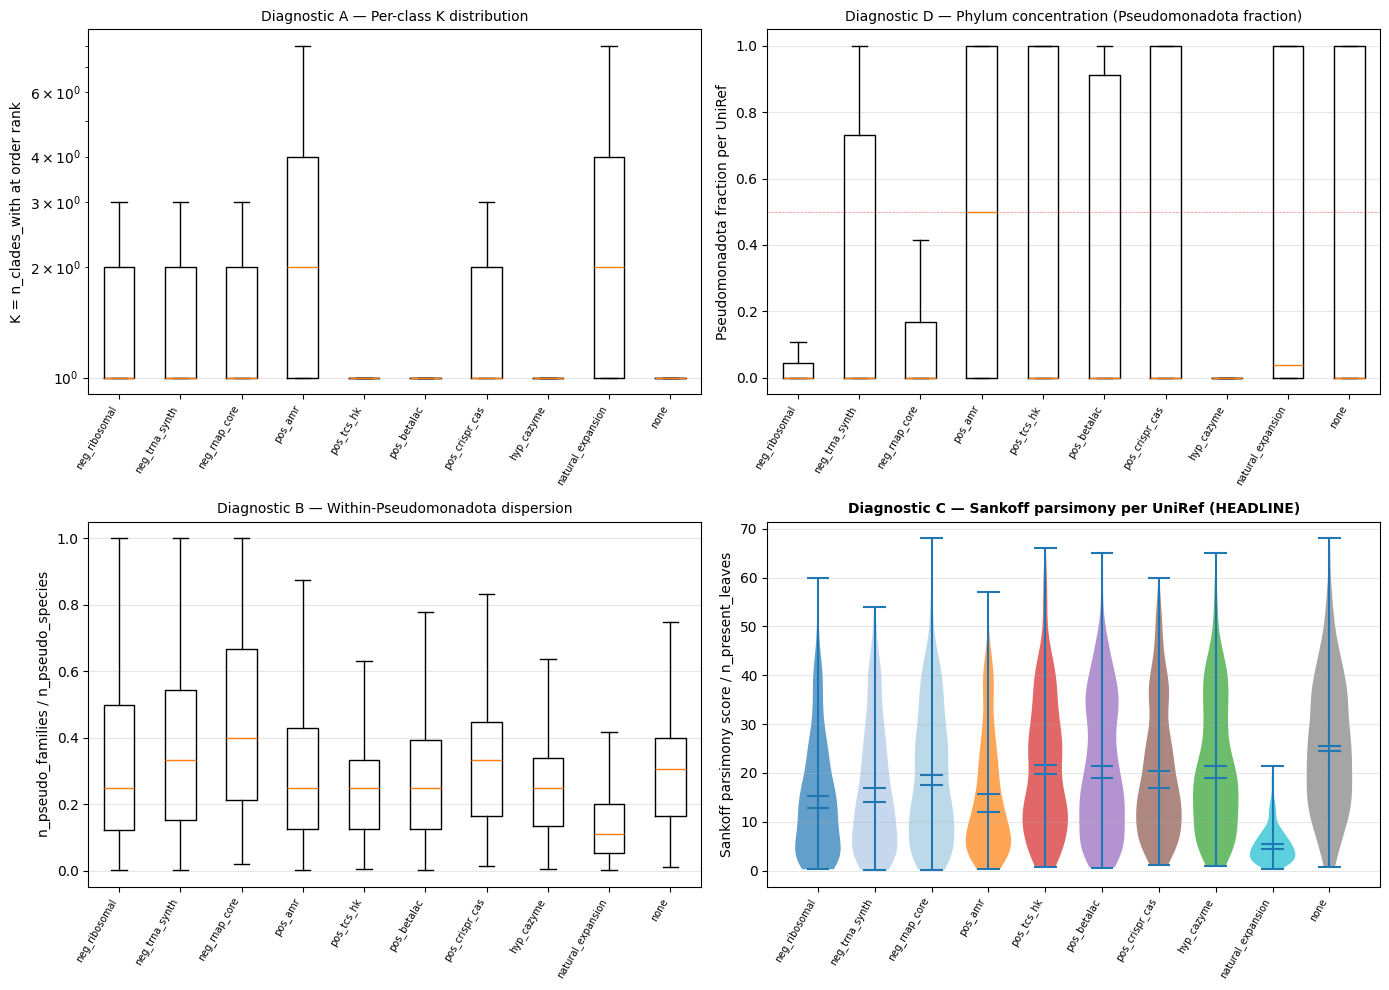

Saved figures/p1b_metric_diagnostic_panels.png
Saved p1b_metric_diagnostic_log.json


In [9]:
control_order = ["neg_ribosomal", "neg_trna_synth", "neg_rnap_core",
                 "pos_amr", "pos_tcs_hk", "pos_betalac", "pos_crispr_cas",
                 "hyp_cazyme", "natural_expansion", "none"]
control_colors = {
    "neg_ribosomal": "#1f77b4", "neg_trna_synth": "#aec7e8", "neg_rnap_core": "#9ecae1",
    "pos_amr": "#ff7f0e", "pos_tcs_hk": "#d62728",
    "pos_betalac": "#9467bd", "pos_crispr_cas": "#8c564b",
    "hyp_cazyme": "#2ca02c", "natural_expansion": "#17becf", "none": "#7f7f7f",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# A: K distribution at order rank
ax = axes[0, 0]
data = [K_per_uref[K_per_uref["control_class"] == c]["n_clades_with"].values for c in control_order]
parts = ax.boxplot([d if len(d) > 0 else [0] for d in data], positions=range(len(control_order)), showfliers=False)
ax.set_xticks(range(len(control_order)))
ax.set_xticklabels(control_order, rotation=60, ha="right", fontsize=7)
ax.set_yscale("log")
ax.set_ylabel("K = n_clades_with at order rank")
ax.set_title("Diagnostic A — Per-class K distribution", fontsize=10)
ax.grid(axis="y", alpha=0.3)

# D: Pseudomonadota concentration
ax = axes[0, 1]
data = [uref_pseudo_frac[uref_pseudo_frac["control_class"] == c]["pseudo_fraction"].values for c in control_order]
ax.boxplot([d if len(d) > 0 else [0] for d in data], positions=range(len(control_order)), showfliers=False)
ax.set_xticks(range(len(control_order)))
ax.set_xticklabels(control_order, rotation=60, ha="right", fontsize=7)
ax.set_ylabel("Pseudomonadota fraction per UniRef")
ax.set_title("Diagnostic D — Phylum concentration (Pseudomonadota fraction)", fontsize=10)
ax.axhline(0.5, color="red", ls="--", lw=0.5, alpha=0.5)
ax.grid(axis="y", alpha=0.3)

# B: Within-Pseudomonadota dispersion
ax = axes[1, 0]
data = [pseudo_per_uref[pseudo_per_uref["control_class"] == c]["within_pseudo_dispersion"].values for c in control_order]
ax.boxplot([d if len(d) > 0 else [0] for d in data], positions=range(len(control_order)), showfliers=False)
ax.set_xticks(range(len(control_order)))
ax.set_xticklabels(control_order, rotation=60, ha="right", fontsize=7)
ax.set_ylabel("n_pseudo_families / n_pseudo_species")
ax.set_title("Diagnostic B — Within-Pseudomonadota dispersion", fontsize=10)
ax.grid(axis="y", alpha=0.3)

# C: Sankoff parsimony (HEADLINE)
ax = axes[1, 1]
data = [sankoff_df[sankoff_df["control_class"] == c]["score_per_present"].values for c in control_order]
parts = ax.violinplot([d if len(d) > 0 else [0] for d in data], positions=range(len(control_order)),
                       showmeans=True, showmedians=True, widths=0.8)
for pc, c in zip(parts["bodies"], control_order):
    pc.set_facecolor(control_colors[c]); pc.set_alpha(0.7)
ax.set_xticks(range(len(control_order)))
ax.set_xticklabels(control_order, rotation=60, ha="right", fontsize=7)
ax.set_ylabel("Sankoff parsimony score / n_present_leaves")
ax.set_title("Diagnostic C — Sankoff parsimony per UniRef (HEADLINE)", fontsize=10, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "p1b_metric_diagnostic_panels.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/p1b_metric_diagnostic_panels.png")

diagnostics["completed_utc"] = time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())
with open(DATA_DIR / "p1b_metric_diagnostic_log.json", "w") as f:
    json.dump(diagnostics, f, indent=2, default=str)
print("Saved p1b_metric_diagnostic_log.json")

## Decision logic

**If Diagnostic C HEADLINE PASSES** (pos HGT > neg housekeeping at p < 0.001 + Cohen's d ≥ 0.3 on Sankoff parsimony):
- The order-rank anomaly is a parent-rank-dispersion artifact
- Methodology is recoverable with tree-aware metric
- Phase 2 KO atlas should use Sankoff parsimony as primary metric (M15 confirmed)

**If Diagnostic C is MARGINAL** (statistical significance but small effect size):
- The metric helps but doesn't fully resolve
- Phase 2 should use Sankoff in combination with other diagnostics

**If Diagnostic C FAILS**:
- Tree-aware metric also fails to discriminate documented HGT from vertical
- Methodology has deeper structural problem
- Phase 2 needs redesign before scaling — possibly: dropping the four-quadrant framework, or using a fundamentally different approach (e.g., gene-tree-vs-species-tree reconciliation per AleRax sub-sampling)

**Diagnostics A, B, D** provide context: do positive controls have biased substrate (Pseudomonadota concentration)? Does within-phylum analysis recover signal? Is K distribution different across classes?